# Trabalho - Bases Engenharia de Software VI - Inteligência Artificial - Seção III - Modelagem de Dados, Treinamento e Avaliação Final do Modelo
Professor: Marcio Andrey Roselli  
Estudante: Bianco Da Costa Oliveira

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("--- RESULTADOS DO BASELINE (REGRESSÃO LOGÍSTICA) ---")
baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print(classification_report(y_test, y_pred_base, target_names=['Regular (0)', 'Bom (1)']))

# Convertendo DataFrames/Arrays para Tensores PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # Redimensionando para [N, 1]

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nDataLoaders criados. Batches de treino: {len(train_loader)}")

--- RESULTADOS DO BASELINE (REGRESSÃO LOGÍSTICA) ---
              precision    recall  f1-score   support

 Regular (0)       0.96      0.82      0.88       277
     Bom (1)       0.40      0.79      0.53        43

    accuracy                           0.81       320
   macro avg       0.68      0.80      0.71       320
weighted avg       0.89      0.81      0.84       320


DataLoaders criados. Batches de treino: 40


Treinando no dispositivo: mps

--- RESULTADOS DA REDE NEURAL ---
              precision    recall  f1-score   support

 Regular (0)       0.96      0.86      0.91       277
     Bom (1)       0.46      0.77      0.58        43

    accuracy                           0.85       320
   macro avg       0.71      0.82      0.74       320
weighted avg       0.89      0.85      0.86       320



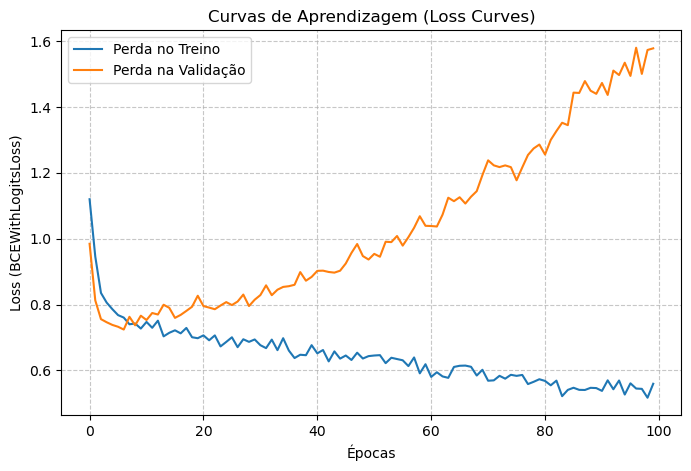

In [2]:

device = torch.device("mps" if torch.backends.mps.is_available() else 
                     "cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}\n")

class WineQualityNN(nn.Module):
    def __init__(self, input_size=11):
        super(WineQualityNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) 
        
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        return self.output(x)

model = WineQualityNN().to(device)

num_negativos = (y_train == 0).sum()
num_positivos = (y_train == 1).sum()
peso_pos = torch.tensor([num_negativos / num_positivos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=peso_pos)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train() 
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(np.mean(batch_losses))
    
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        y_test_device = y_test_tensor.to(device)
        val_pred = model(X_test_device)
        val_loss = criterion(val_pred, y_test_device)
        val_losses.append(val_loss.item())

model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_device)
    y_pred_nn = (torch.sigmoid(y_pred_logits) >= 0.5).cpu().numpy().astype(int)

print("--- RESULTADOS DA REDE NEURAL ---")
print(classification_report(y_test, y_pred_nn, target_names=['Regular (0)', 'Bom (1)']))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Perda no Treino')
plt.plot(val_losses, label='Perda na Validação')
plt.title('Curvas de Aprendizagem (Loss Curves)')
plt.xlabel('Épocas')
plt.ylabel('Loss (BCEWithLogitsLoss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()